Projected points:
[[277.45363065 355.53950334]
 [389.49496304 352.71277621]
 [389.49496304 465.42555242]
 [277.45363065 471.07900667]
 [265.18653867 341.1525509 ]
 [363.83979983 338.97934117]
 [363.83979983 437.95868234]
 [265.18653867 442.30510181]]


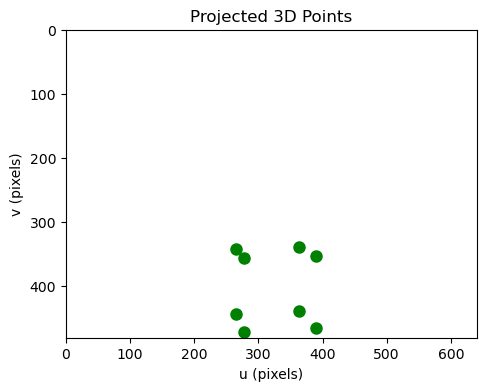

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -------------------------------
# 1. CAMERA INTRINSICS
# -------------------------------
fx = 800
fy = 800
cx = 320
cy = 240

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float64)

dist_coeffs = np.zeros(5)   # No distortion

# -------------------------------
# 2. CAMERA EXTRINSICS
# -------------------------------
yaw   = np.deg2rad(0)
pitch = np.deg2rad(-10)
roll  = np.deg2rad(0)

# Build rotation matrix
R, _ = cv2.Rodrigues(np.array([roll, pitch, yaw]))
rvec, _ = cv2.Rodrigues(R)

tvec = np.array([[0.5],
                 [1.0],
                 [2.0]], dtype=np.float64)

# -------------------------------
# 3. DEFINE 3D POINTS
# -------------------------------
cube_points = np.array([
    [0, 0, 5],
    [1, 0, 5],
    [1, 1, 5],
    [0, 1, 5],
    [0, 0, 6],
    [1, 0, 6],
    [1, 1, 6],
    [0, 1, 6],
], dtype=np.float64)

# -------------------------------
# 4. PROJECT POINTS
# -------------------------------
image_points, _ = cv2.projectPoints(
    cube_points,
    rvec,
    tvec,
    K,
    dist_coeffs
)

image_points = image_points.squeeze()

print("Projected points:")
print(image_points)

# -------------------------------
# 5. DISPLAY USING MATPLOTLIB
# -------------------------------
img_h, img_w = 480, 640

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)  # invert y-axis to match image coords
ax.set_aspect('equal')
ax.set_title("Projected 3D Points")
ax.set_xlabel("u (pixels)")
ax.set_ylabel("v (pixels)")

# plot points
for (u, v) in image_points:
    ax.plot(u, v, "go", markersize=8)

plt.show()


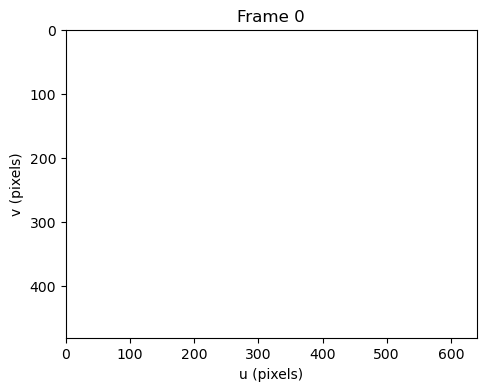

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------------------
# 1. Camera intrinsics
# --------------------------------
fx = fy = 800
cx, cy = 320, 240

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float64)

dist_coeffs = np.zeros(5)

# --------------------------------
# 2. 3D object (cube)
# --------------------------------
cube_points = np.array([
    [0, 0, 5],
    [1, 0, 5],
    [1, 1, 5],
    [0, 1, 5],
    [0, 0, 6],
    [1, 0, 6],
    [1, 1, 6],
    [0, 1, 6],
], dtype=np.float64)

# --------------------------------
# 3. Camera trajectory (orbiting)
# --------------------------------
def camera_pose(t):
    """Return camera rvec, tvec at time t"""
    radius = 3        # orbit radius
    height = 2        # constant height
    angle = t * 0.05  # angular speed

    # camera position in world coordinates
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    z = height
    tvec = np.array([[x], [y], [z]], dtype=np.float64)

    # camera looks at cube center
    target = np.array([0.5, 0.5, 5.5])
    forward = (target - np.array([x, y, z]))
    forward /= np.linalg.norm(forward)

    # build orthonormal basis
    up = np.array([0, 0, 1], dtype=np.float64)
    right = np.cross(forward, up)
    right /= np.linalg.norm(right)
    up = np.cross(right, forward)

    R_wc = np.vstack([right, up, -forward])  # world->camera basis
    rvec, _ = cv2.Rodrigues(R_wc)

    return rvec, tvec

# --------------------------------
# 4. Setup matplotlib figure
# --------------------------------
img_h, img_w = 480, 640

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_aspect("equal")
ax.set_title("Projection of Moving Camera")
ax.set_xlabel("u (pixels)")
ax.set_ylabel("v (pixels)")

points_plot, = ax.plot([], [], 'go', markersize=8)

# --------------------------------
# 5. Animation update function
# --------------------------------
def update(frame):
    rvec, tvec = camera_pose(frame)

    image_points, _ = cv2.projectPoints(
        cube_points,
        rvec,
        tvec,
        K,
        dist_coeffs
    )
    image_points = image_points.squeeze()

    points_plot.set_data(image_points[:, 0], image_points[:, 1])
    ax.set_title(f"Frame {frame}")

    return points_plot,

# --------------------------------
# 6. Run animation
# --------------------------------
anim = FuncAnimation(fig, update, frames=200, interval=50)
HTML(anim.to_jshtml())
